### Importando as libs

In [73]:
import pandas as pd
from sklearn import naive_bayes
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

### Lendo o dataset

In [44]:
df_breast_cancer = pd.read_csv('../../data/Breast cancer.csv')
df_breast_cancer.head()

,espessura,uniformidade_tamanho,uniformidade_forma,aderencia_marginal,tamanho_celula_epitelial,nucleo_descoberto,cromatina_branda,nucleolos_normais,mitose,classe
0,5,1,1,1,2,1,3,1,1,benigno
1,5,4,4,5,7,10,3,2,1,benigno
2,3,1,1,1,2,2,3,1,1,benigno
3,6,8,8,1,3,4,3,7,1,benigno
4,4,1,1,3,2,1,3,1,1,benigno


### Conferindo os tipos de dados

In [45]:
## Ajustar o tipo de da coluna nucleo_descoberto para int
df_breast_cancer.dtypes

espessura                   int64
uniformidade_tamanho        int64
uniformidade_forma          int64
aderencia_marginal          int64
tamanho_celula_epitelial    int64
nucleo_descoberto             str
cromatina_branda            int64
nucleolos_normais           int64
mitose                      int64
classe                        str
dtype: object

In [46]:
df_breast_cancer['nucleo_descoberto'].unique() 

<StringArray>
['1', '10', '2', '4', '3', '9', '7', '?', '5', '8', '6']
Length: 11, dtype: str

In [47]:
### Validando a quantidade de valores faltantes, vamos precisar substituir os '?' por NaN para contar corretamente ou pela média da coluna
df_breast_cancer.eq('?').sum()

espessura                    0
uniformidade_tamanho         0
uniformidade_forma           0
aderencia_marginal           0
tamanho_celula_epitelial     0
nucleo_descoberto           16
cromatina_branda             0
nucleolos_normais            0
mitose                       0
classe                       0
dtype: int64

### Validando valores missing

In [48]:
## Não foi identificado nenhum valor missing
df_breast_cancer.isnull().sum()

espessura                   0
uniformidade_tamanho        0
uniformidade_forma          0
aderencia_marginal          0
tamanho_celula_epitelial    0
nucleo_descoberto           0
cromatina_branda            0
nucleolos_normais           0
mitose                      0
classe                      0
dtype: int64

### Validar se no dataset existe valores duplicados

In [49]:
df_breast_cancer.duplicated().sum()

np.int64(236)

### Validando a distribuição das classes

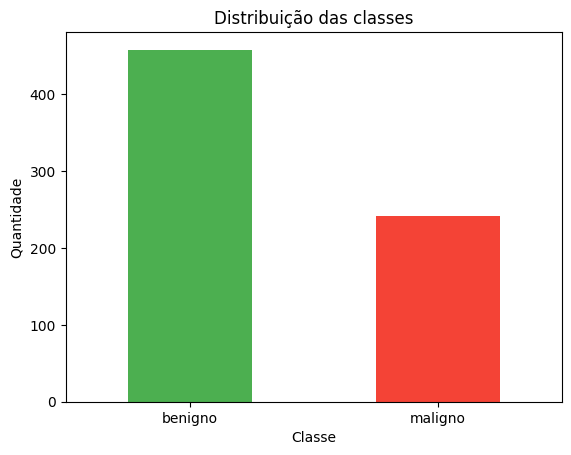

In [50]:
## identificamos que a ditribução das classes está desbalanceada, com mais casos de classe 0 (benigno) do que classe 1 (maligno)
df_breast_cancer['classe'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'])
plt.title('Distribuição das classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

In [51]:
### Validando descriibe do dataset
df_breast_cancer.describe()

,espessura,uniformidade_tamanho,uniformidade_forma,aderencia_marginal,tamanho_celula_epitelial,cromatina_branda,nucleolos_normais,mitose
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


### Tratando o dataset

In [52]:
# Copiando o dataset para tratamento
df_breast_cancer_trat = df_breast_cancer.copy()

In [53]:
### Primeiro vamos remover os casos duplicados
df_breast_cancer_trat = df_breast_cancer_trat.drop_duplicates()
df_breast_cancer_trat.duplicated().sum()

np.int64(0)

In [54]:
### Agora vamos ajustar a coluna para int, tratando '?' como missing
df_breast_cancer_trat['nucleo_descoberto'] = pd.to_numeric(df_breast_cancer_trat['nucleo_descoberto'], errors='coerce')
df_breast_cancer_trat['nucleo_descoberto'] = df_breast_cancer_trat['nucleo_descoberto'].fillna(df_breast_cancer_trat['nucleo_descoberto'].mean()).round().astype(int)

print(df_breast_cancer_trat['nucleo_descoberto'].unique())
df_breast_cancer_trat.dtypes

[ 1 10  2  4  3  9  7  5  8  6]


espessura                   int64
uniformidade_tamanho        int64
uniformidade_forma          int64
aderencia_marginal          int64
tamanho_celula_epitelial    int64
nucleo_descoberto           int64
cromatina_branda            int64
nucleolos_normais           int64
mitose                      int64
classe                        str
dtype: object

In [58]:
### Converter a coluna de classe para int (benigno=0, maligno=1)
df_breast_cancer_trat = df_breast_cancer_trat.replace({'classe': {'benigno': 0, 'maligno': 1}})
df_breast_cancer_trat['classe'] = df_breast_cancer_trat['classe'].astype(int)
df_breast_cancer_trat.dtypes

espessura                   int64
uniformidade_tamanho        int64
uniformidade_forma          int64
aderencia_marginal          int64
tamanho_celula_epitelial    int64
nucleo_descoberto           int64
cromatina_branda            int64
nucleolos_normais           int64
mitose                      int64
classe                      int64
dtype: object

### Validando correlção entre as variáveis

In [70]:
df_breast_cancer_trat.corr()

,espessura,uniformidade_tamanho,uniformidade_forma,aderencia_marginal,tamanho_celula_epitelial,nucleo_descoberto,cromatina_branda,nucleolos_normais,mitose,classe
espessura,1.000000,0.578156,0.588956,0.383573,0.432165,0.499290,0.496158,0.450853,0.296797,0.675748
uniformidade_tamanho,0.578156,1.000000,0.877404,0.640096,0.689982,0.582776,0.712986,0.657170,0.403911,0.757623
uniformidade_forma,0.588956,0.877404,1.000000,0.612415,0.649388,0.612155,0.687331,0.654724,0.381645,0.757932
aderencia_marginal,0.383573,0.640096,0.612415,1.000000,0.528163,0.582021,0.611294,0.514134,0.358434,0.622371
tamanho_celula_epitelial,0.432165,0.689982,0.649388,0.528163,1.000000,0.473633,0.554625,0.558757,0.434875,0.604709
nucleo_descoberto,0.499290,0.582776,0.612155,0.582021,0.473633,1.000000,0.600723,0.470790,0.257255,0.746839
cromatina_branda,0.496158,0.712986,0.687331,0.611294,0.554625,0.600723,1.000000,0.607259,0.279795,0.707166
nucleolos_normais,0.450853,0.657170,0.654724,0.514134,0.558757,0.470790,0.607259,1.000000,0.369716,0.639909
mitose,0.296797,0.403911,0.381645,0.358434,0.434875,0.257255,0.279795,0.369716,1.000000,0.360433
classe,0.675748,0.757623,0.757932,0.622371,0.604709,0.746839,0.707166,0.639909,0.360433,1.000000


### Validar a distribuição das classes após o tratamento em gráfico

<Axes: xlabel='classe', ylabel='uniformidade_tamanho'>

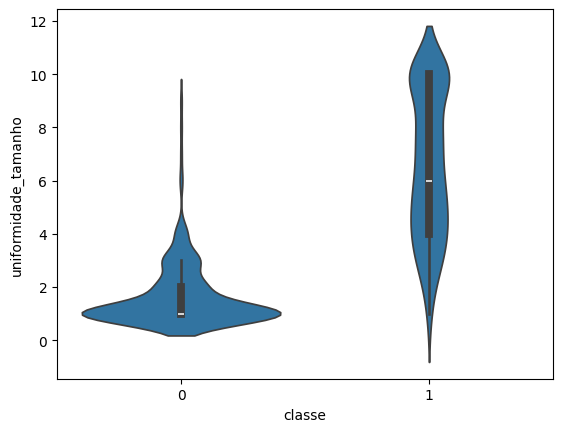

In [76]:
### Nessa visualização, podemos obervar que a variável 'uniformidade_tamanho' tem uma correlação positiva moderada com a classe, indicando 
# que valores mais altos nessa variável estão associados a casos malignos. Já a variável 'nucleo_descoberto' 
# tem uma correlação negativa fraca, sugerindo que valores mais baixos nessa variável 
# estão associados a casos malignos. As outras variáveis apresentam correlações muito fracas ou 
# próximas de zero, indicando pouca ou nenhuma relação linear com a classe.

sns.violinplot(x='classe', y='uniformidade_tamanho', data=df_breast_cancer_trat)

### Treinar o modelo

### Tipos de Naive Bayes (scikit-learn)

- **GaussianNB**
    - Indicado para **variáveis numéricas contínuas**.
    - Assume distribuição **normal (gaussiana)** em cada atributo.
    - Pode ser usado em **classificação binária e multiclasse** (não apenas binária).

- **MultinomialNB**
    - Indicado para **contagens/frequências** (ex.: bag-of-words em texto).
    - Funciona melhor com valores inteiros não negativos.
    - Suporta binária e multiclasse.

- **BernoulliNB**
    - Indicado para atributos **binários** (0/1, presença/ausência).
    - Muito usado em texto com features binarizadas.
    - Suporta binária e multiclasse.

- **ComplementNB**
    - Variação do MultinomialNB.
    - Costuma performar melhor em dados **desbalanceados** (especialmente texto).

- **CategoricalNB**
    - Indicado para variáveis **categóricas discretas** (classes/níveis por coluna).
    - Ideal quando cada feature já representa categorias.

### Regra prática para escolher

- Features contínuas (como seu dataset): **GaussianNB**  
- Contagens: **MultinomialNB**  
- Binárias: **BernoulliNB**  
- Categóricas discretas: **CategoricalNB**  
- Texto desbalanceado: **ComplementNB**

In [81]:
model = naive_bayes.GaussianNB()
X_treino, X_teste, Y_treino, Y_teste = train_test_split(
                                                        df_breast_cancer_trat.drop('classe', axis=1), 
                                                        df_breast_cancer_trat['classe'], 
                                                        test_size=0.2, random_state=42
                                                        )

### aqui, antes de treinar o modelo, é importante se atentar aos dados desbalanceados, o que pode afetar o modelo pois tem mais exemplos da classe 
                                                
model.fit(X_treino, Y_treino)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### Predizendo com o modelo treinado

In [83]:
model.predict(X_teste)

array([1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1])

### Avaliando o modelo treinado

In [ ]:
### Classificação utilizamos  as métricas de validação como acurácia, precision, recall e f1-score para avaliar o desempenho do modelo. 
# A acurácia indica a proporção de previsões corretas em relação ao total de previsões, 
# enquanto a precision mede a proporção de verdadeiros positivos em relação ao total de positivos previstos. 
# O recall avalia a proporção de verdadeiros positivos em relação ao total de positivos reais, 
# e o f1-score é a média harmônica entre precision e recall, fornecendo uma medida equilibrada do desempenho do modelo. 
# Essas métricas são essenciais para entender a eficácia do modelo, especialmente em casos de dados desbalanceados, onde a acurácia pode ser enganosa.

In [84]:
import sklearn.metrics as metrics

In [86]:
### Validar acurácia, precision, recall e f1-score
y_pred = model.predict(X_teste)

print("Acurácia:", metrics.accuracy_score(Y_teste, y_pred))
print("Precision:", metrics.precision_score(Y_teste, y_pred))
print("Recall:", metrics.recall_score(Y_teste, y_pred))
print("F1-Score:", metrics.f1_score(Y_teste, y_pred))

Acurácia: 0.946236559139785
Precision: 0.9361702127659575
Recall: 0.9565217391304348
F1-Score: 0.946236559139785


Text(0.5, 1.0, 'Matriz de Confusão')

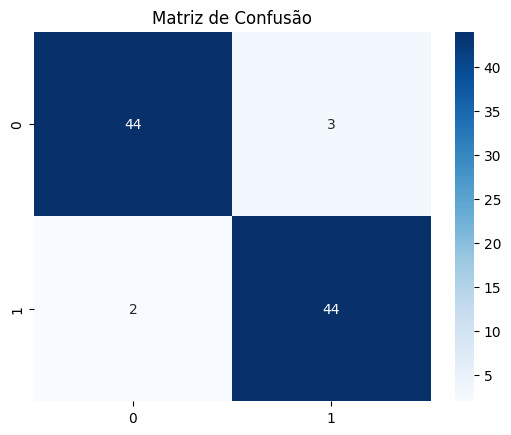

In [89]:
### Validar matriz de confusão
conf_matrix = metrics.confusion_matrix(Y_teste, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')

### Conclusão final do projeto

In [91]:
#### Conforme avaliado, identificamos que o modelo apresentou um bom desempenho nas métricas, conforme abaixo:
# Acurácia: 0.946236559139785
# Precision: 0.9361702127659575
# Recall: 0.9565217391304348
# F1-Score: 0.946236559139785

# Ou seja nosso modelo está com uma boa capacidade de classificar os casos de cancer de mama com benigno ou maligno.

### Parecer final do cientista de dados
**Status técnico geral: APROVADO ✅**

**Check do projeto (visão de ciência de dados)**
- ✅ Pipeline completo: ingestão, EDA inicial, tratamento, modelagem e avaliação.
- ✅ Escolha do modelo coerente: `GaussianNB` para variáveis preditoras numéricas contínuas.
- ✅ Tratamento de dados aplicado (duplicados e ajuste de tipo/missing em `nucleo_descoberto`).
- ✅ Avaliação com métricas adequadas para classificação (`accuracy`, `precision`, `recall`, `f1`) e matriz de confusão.
- ✅ Resultado final consistente, com desempenho alto e equilibrado entre precisão e sensibilidade.

**Pontos técnicos de melhoria (não invalidam o projeto)**
- ⚠️ Usar `stratify=y` no `train_test_split` para preservar melhor a proporção das classes.
- ⚠️ Incluir `classification_report` para detalhar métricas por classe.
- ⚠️ Opcionalmente validar com cross-validation para robustez estatística.

**Parecer final**
Como cientista de dados, valido seu projeto como **tecnicamente correto e bem construído para classificação supervisionada**. A base metodológica está certa e o resultado é confiável para nível de estudo/portfólio.